# Notebook 10 - Cross-Modal / Gated Fusion Model

Notebook ini adalah **model utama multimodal** untuk penelitian MABSA hotel review.

Tujuan:

1. Menguji apakah visual evidence dapat meningkatkan prediksi `label_text_*` dibanding text-only IndoBERT.
2. Mengatasi kelemahan Notebook 09, yaitu late fusion yang mudah overfit dan tidak memahami noise visual.
3. Membuat model fusion yang tetap aman: teks menjadi anchor utama, sedangkan gambar masuk melalui learned gate.

Target utama tetap:

`label_text_Kamar`, `label_text_Kebersihan`, `label_text_Pelayanan`, `label_text_Harga`, `label_text_Lokasi`, `label_text_Fasilitas`, `label_text_Makanan`.

Image feature dipakai sebagai **auxiliary evidence**, bukan target pengganti.

## Dasar Metodologis

Desain Notebook 10 dibuat berdasarkan temuan dari Notebook 07 sampai 09:

1. Text-only IndoBERT masih menjadi baseline terkuat untuk target `label_text_*`.
2. Image-only CLIP kuat untuk aspek visual, tetapi tidak langsung cocok sebagai prediktor label teks.
3. Late fusion sederhana belum mengalahkan text-only di test set, menandakan visual noise dan mismatch text-image harus ditangani oleh model yang belajar gate, bukan bobot manual.

Dasar paper:

1. **MIMN** memperkenalkan MABSA sebagai tugas yang memerlukan interaksi text-image-aspect, bukan sekadar sentiment umum.
2. **M2DF** menunjukkan bahwa image yang tidak relevan terhadap teks dapat menjadi noise dan merusak pembelajaran MABSA.
3. **AMIFN** menekankan masalah aspect-image irrelevant dan menggunakan mekanisme fusion yang dipandu aspek.
4. **Gated attention/fusion** pada multimodal sentiment analysis dipakai untuk mengurangi informasi redundant/noisy dari modality tambahan.
5. **CLIP** dipakai sebagai visual representation learner yang transferable.

Implikasi untuk desain model:

- IndoBERT checkpoint dari Notebook 07 dipakai sebagai teacher/anchor.
- CLIP visual feature dari Notebook 08 dipakai sebagai visual evidence.
- Gate dipelajari per aspek agar model bisa memakai gambar untuk `Kamar`, `Kebersihan`, `Lokasi`, `Fasilitas`, atau `Makanan`, tetapi menekan visual noise untuk aspek seperti `Harga` dan `Pelayanan`.
- Relation group dari Notebook 02/03 dipakai sebagai sinyal konteks, bukan aturan keras.

Referensi:

- Xu, Mao, & Chen (2019), *Multi-Interactive Memory Network for Aspect Based Multimodal Sentiment Analysis*. https://ojs.aaai.org/index.php/AAAI/article/view/3807
- Zhao et al. (2023), *M2DF: Multi-grained Multi-curriculum Denoising Framework for Multimodal Aspect-based Sentiment Analysis*. https://arxiv.org/abs/2310.14605
- Yang et al. (2024), *AMIFN: Aspect-guided multi-view interactions and fusion network for multimodal aspect-based sentiment analysis*. https://doi.org/10.1016/j.neucom.2023.127222
- Yang et al. (2022), *Gated attention fusion network for multimodal sentiment classification*. https://doi.org/10.1016/j.knosys.2021.107990
- Radford et al. (2021), *Learning Transferable Visual Models From Natural Language Supervision*. https://proceedings.mlr.press/v139/radford21a.html

### 1. Import Library dan Persiapan Lingkungan Eksekusi


In [1]:
from pathlib import Path
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
from collections import defaultdict

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)

SEED = 42

ASPECTS = ["Kamar", "Kebersihan", "Pelayanan", "Harga", "Lokasi", "Fasilitas", "Makanan"]
LABEL_ORDER = ["None", "Negatif", "Netral", "Positif"]
LABEL_TO_ID = {"None": 0, "Negatif": 1, "Netral": 2, "Positif": 3}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}
ASPECT_TO_ID = {aspect: idx for idx, aspect in enumerate(ASPECTS)}
SPLIT_TO_ID = {"train": 0, "val": 1, "test": 2}
ID_TO_SPLIT = {v: k for k, v in SPLIT_TO_ID.items()}

RELATION_GROUP_ORDER = [
    "correlated",
    "uncorrelated",
    "image_aspect_only",
    "text_aspect_only",
    "both_no_aspect",
    "contradiction",
    "other",
]
RELATION_GROUP_TO_ID = {name: idx for idx, name in enumerate(RELATION_GROUP_ORDER)}

IS_KAGGLE = Path("/kaggle").exists()
OUTPUT_DIR = Path("/kaggle/working/mabsa_gated_fusion_model_outputs") if IS_KAGGLE else Path("mabsa_gated_fusion_model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = int(os.environ.get("GATED_FUSION_MAX_LENGTH", "256"))
BATCH_SIZE = int(os.environ.get("GATED_FUSION_BATCH_SIZE", "16"))
GRADIENT_ACCUMULATION_STEPS = int(os.environ.get("GATED_FUSION_GRAD_ACCUM", "1"))
NUM_WORKERS = int(os.environ.get("GATED_FUSION_NUM_WORKERS", "0"))

STAGE1_EPOCHS = int(os.environ.get("GATED_STAGE1_EPOCHS", "3"))
STAGE2_EPOCHS = int(os.environ.get("GATED_STAGE2_EPOCHS", "7"))
EARLY_STOPPING_PATIENCE = int(os.environ.get("GATED_EARLY_STOPPING_PATIENCE", "4"))

LR_ENCODER = float(os.environ.get("GATED_LR_ENCODER", "1e-5"))
LR_HEADS = float(os.environ.get("GATED_LR_HEADS", "5e-5"))
LR_FUSION = float(os.environ.get("GATED_LR_FUSION", "3e-4"))
WEIGHT_DECAY = float(os.environ.get("GATED_WEIGHT_DECAY", "1e-4"))
MAX_GRAD_NORM = float(os.environ.get("GATED_MAX_GRAD_NORM", "1.0"))
UNFREEZE_LAST_N_LAYERS = int(os.environ.get("GATED_UNFREEZE_LAST_N_LAYERS", "4"))

TEXT_AUX_LOSS_WEIGHT = float(os.environ.get("GATED_TEXT_AUX_LOSS_WEIGHT", "0.20"))
TEXT_DISTILL_LOSS_WEIGHT = float(os.environ.get("GATED_TEXT_DISTILL_LOSS_WEIGHT", "0.05"))
GATE_PRIOR_LOSS_WEIGHT = float(os.environ.get("GATED_GATE_PRIOR_LOSS_WEIGHT", "0.01"))
DISTILL_TEMPERATURE = float(os.environ.get("GATED_DISTILL_TEMPERATURE", "2.0"))

CLASS_WEIGHT_POWER = float(os.environ.get("GATED_CLASS_WEIGHT_POWER", "0.5"))
CLASS_WEIGHT_CLIP_MAX = float(os.environ.get("GATED_CLASS_WEIGHT_CLIP_MAX", "10.0"))
USE_CLASS_WEIGHTS = os.environ.get("GATED_USE_CLASS_WEIGHTS", "1") == "1"
USE_AMP = os.environ.get("GATED_USE_AMP", "1") == "1"

FUSION_DROPOUT = float(os.environ.get("GATED_FUSION_DROPOUT", "0.25"))
INITIAL_GATE_BIAS = float(os.environ.get("GATED_INITIAL_GATE_BIAS", "-2.5"))

print("Output directory:", OUTPUT_DIR)
print("Kaggle environment:", IS_KAGGLE)
print("Batch size:", BATCH_SIZE)
print("Stage epochs:", STAGE1_EPOCHS, STAGE2_EPOCHS)
print("LR encoder/heads/fusion:", LR_ENCODER, LR_HEADS, LR_FUSION)
print("Aux/distill/gate loss:", TEXT_AUX_LOSS_WEIGHT, TEXT_DISTILL_LOSS_WEIGHT, GATE_PRIOR_LOSS_WEIGHT)

Output directory: /kaggle/working/mabsa_gated_fusion_model_outputs
Kaggle environment: True
Batch size: 16
Stage epochs: 3 7
LR encoder/heads/fusion: 1e-05 5e-05 0.0003
Aux/distill/gate loss: 0.2 0.05 0.01


### 2. Pengaturan Seed untuk Reproduksibilitas (PyTorch, Numpy, Random)


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
    except Exception:
        pass


set_seed(SEED)

### 3. Validasi Lingkungan PyTorch GPU dan Neural Network Dependencies


In [3]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except ImportError as exc:
    raise ImportError("PyTorch tidak tersedia. Jalankan Notebook 10 di Kaggle GPU runtime.") from exc

try:
    from transformers import AutoModel
except ImportError:
    if IS_KAGGLE:
        print("transformers belum tersedia. Mencoba install di Kaggle...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
        from transformers import AutoModel
    else:
        raise

try:
    from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
except ImportError:
    if IS_KAGGLE:
        print("scikit-learn belum tersedia. Mencoba install di Kaggle...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
        from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
    else:
        raise

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 3))

Device: cuda
GPU: Tesla T4
Total VRAM GB: 14.563


## Resolve Inputs

Notebook ini membutuhkan output:

- Notebook 03: `final_review_dataset_primary_training.csv`
- Notebook 05: `indobert_primary_training_maxlen256.npz`
- Notebook 07: `best_text_only_indobert.pt`
- Notebook 08: `clip_image_features_primary_training.npz` dan `best_image_only_clip_head.pt`
- Notebook 09: opsional untuk perbandingan hasil late fusion

### 4. Fungsi Pencarian Path Model Checkpoints dan Fitur Gambar Lokal


In [4]:
SEARCH_CACHE = {}


def all_search_roots():
    roots = []
    if IS_KAGGLE:
        roots.extend([Path("/kaggle/working"), Path("/kaggle/input")])
    roots.extend([
        Path(r"C:\Users\cencen04_\Documents\Codex\2026-05-23\files-mentioned-by-the-user-data"),
        Path(r"G:\Skripsi\Data Preprocessing"),
        Path(r"C:\Users\cencen04_\Downloads"),
    ])
    return [root for root in roots if root.exists()]


def path_score(path, preferred_substrings=None):
    text = str(path).replace("\\", "/").lower()
    score = 0
    preferred_substrings = preferred_substrings or []
    for idx, token in enumerate(preferred_substrings):
        if token.lower() in text:
            score += 100 - idx
    if "/kaggle/working/" in text:
        score += 20
    if "/kaggle/input/" in text:
        score += 10
    if "mabsa" in text:
        score += 5
    return score


def find_file(filename, preferred_substrings=None, required=True):
    cache_key = (filename, tuple(preferred_substrings or []))
    if cache_key in SEARCH_CACHE:
        return SEARCH_CACHE[cache_key]

    candidates = []
    for root in all_search_roots():
        direct = root / filename
        if direct.exists():
            candidates.append(direct)
        try:
            candidates.extend(root.rglob(filename))
        except Exception as exc:
            print(f"Skip search root {root}: {exc}")

    candidates = sorted(set(candidates), key=lambda p: path_score(p, preferred_substrings), reverse=True)
    if candidates:
        SEARCH_CACHE[cache_key] = candidates[0]
        return candidates[0]
    if required:
        raise FileNotFoundError(f"Tidak menemukan {filename}. Tambahkan output notebook sebelumnya sebagai Kaggle input.")
    return None


def find_glob(pattern, preferred_substrings=None, required=True):
    cache_key = ("glob", pattern, tuple(preferred_substrings or []))
    if cache_key in SEARCH_CACHE:
        return SEARCH_CACHE[cache_key]

    candidates = []
    for root in all_search_roots():
        try:
            candidates.extend(root.rglob(pattern))
        except Exception as exc:
            print(f"Skip glob root {root}: {exc}")

    candidates = sorted(set(candidates), key=lambda p: path_score(p, preferred_substrings), reverse=True)
    if candidates:
        SEARCH_CACHE[cache_key] = candidates[0]
        return candidates[0]
    if required:
        raise FileNotFoundError(f"Tidak menemukan pattern {pattern}.")
    return None


FINAL_REVIEW_PATH = find_file("final_review_dataset_primary_training.csv", ["mabsa_final_dataset_outputs", "03"])
TEXT_NPZ_PATH = find_glob("indobert_primary_training_maxlen*.npz", ["mabsa_text_indobert_preprocessing_outputs", "05"])
TEXT_METADATA_PATH = find_file("text_preprocessed_primary_training.csv", ["mabsa_text_indobert_preprocessing_outputs", "05"])
TEXT_CHECKPOINT_PATH = find_file("best_text_only_indobert.pt", ["mabsa_text_only_indobert_baseline_outputs", "07"])
IMAGE_FEATURE_CACHE_PATH = find_file("clip_image_features_primary_training.npz", ["mabsa_image_only_clip_baseline_outputs", "08"])
IMAGE_HEAD_CHECKPOINT_PATH = find_file("best_image_only_clip_head.pt", ["mabsa_image_only_clip_baseline_outputs", "08"])

TEXT_METRICS_PATH = find_file("final_text_only_indobert_metrics.csv", ["mabsa_text_only_indobert_baseline_outputs", "07"], required=False)
IMAGE_METRICS_PATH = find_file("final_image_only_clip_metrics.csv", ["mabsa_image_only_clip_baseline_outputs", "08"], required=False)
LATE_FUSION_COMPARISON_PATH = find_file("notebook07_08_09_comparison.csv", ["mabsa_late_fusion_multimodal_baseline_outputs", "09"], required=False)

print("Final review:", FINAL_REVIEW_PATH)
print("Text NPZ:", TEXT_NPZ_PATH)
print("Text metadata:", TEXT_METADATA_PATH)
print("Text checkpoint:", TEXT_CHECKPOINT_PATH)
print("Image feature cache:", IMAGE_FEATURE_CACHE_PATH)
print("Image head checkpoint:", IMAGE_HEAD_CHECKPOINT_PATH)
print("Notebook 09 comparison:", LATE_FUSION_COMPARISON_PATH)

Final review: /kaggle/input/notebooks/vince0014/03-final-dataset-builder-and-splits/mabsa_final_dataset_outputs/final_review_dataset_primary_training.csv
Text NPZ: /kaggle/input/notebooks/vince0014/05-text-preprocessing-indobert-dataset/mabsa_text_indobert_preprocessing_outputs/indobert_primary_training_maxlen256.npz
Text metadata: /kaggle/input/notebooks/vince0014/05-text-preprocessing-indobert-dataset/mabsa_text_indobert_preprocessing_outputs/text_preprocessed_primary_training.csv
Text checkpoint: /kaggle/input/notebooks/vince0014/07-text-only-baseline-indobert/mabsa_text_only_indobert_baseline_outputs/best_text_only_indobert.pt
Image feature cache: /kaggle/input/notebooks/vince0014/08-image-only-baseline-vit-or-clip/mabsa_image_only_clip_baseline_outputs/clip_image_features_primary_training.npz
Image head checkpoint: /kaggle/input/notebooks/vince0014/08-image-only-baseline-vit-or-clip/mabsa_image_only_clip_baseline_outputs/best_image_only_clip_head.pt
Notebook 09 comparison: /kaggle

### 5. Memuat Dataset Utama, Visual Features, dan Data Target Label


In [5]:
def normalize_label_value(value):
    if pd.isna(value):
        return "None"
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "null", "<na>"}:
        return "None"
    lookup = {
        "none": "None",
        "negatif": "Negatif",
        "netral": "Netral",
        "positif": "Positif",
    }
    return lookup.get(text.lower(), text)


def relation_group(value):
    text = str(value)
    if text == "correlated_non_contradictive":
        return "correlated"
    if text == "uncorrelated_different_aspects":
        return "uncorrelated"
    if text == "image_aspect_only":
        return "image_aspect_only"
    if text == "text_aspect_only":
        return "text_aspect_only"
    if text == "both_no_aspect":
        return "both_no_aspect"
    if text == "correlated_but_contradictive":
        return "contradiction"
    return "other"


final_review = pd.read_csv(FINAL_REVIEW_PATH, keep_default_na=False)
text_metadata = pd.read_csv(TEXT_METADATA_PATH, keep_default_na=False)
text_npz = np.load(TEXT_NPZ_PATH, allow_pickle=True)

for df in [final_review, text_metadata]:
    df["ID_Review"] = df["ID_Review"].astype(str)

target_labels = np.zeros((len(final_review), len(ASPECTS)), dtype=np.int64)
invalid_rows = []
for aspect_idx, aspect in enumerate(ASPECTS):
    col = f"label_text_{aspect}"
    if col not in final_review.columns:
        raise ValueError(f"Kolom target hilang: {col}")
    normalized = final_review[col].map(normalize_label_value)
    bad_mask = ~normalized.isin(LABEL_ORDER)
    if bad_mask.any():
        for row in final_review.loc[bad_mask, ["ID_Review", col]].head(20).itertuples(index=False):
            invalid_rows.append({"aspect": aspect, "ID_Review": row[0], "label": row[1]})
    final_review[col] = normalized
    target_labels[:, aspect_idx] = normalized.map(LABEL_TO_ID).astype(np.int64).to_numpy()

invalid_df = pd.DataFrame(invalid_rows)
if len(invalid_df):
    display(invalid_df)
    raise ValueError("Ada label target invalid.")

review_ids = final_review["ID_Review"].astype(str).to_numpy()
split_names = final_review["split"].astype(str).to_numpy()
split_ids = np.asarray([SPLIT_TO_ID[x] for x in split_names], dtype=np.int64)
relation_groups = final_review["relation_category"].map(relation_group).to_numpy()
relation_group_ids = np.asarray([RELATION_GROUP_TO_ID.get(x, RELATION_GROUP_TO_ID["other"]) for x in relation_groups], dtype=np.int64)

print("final_review:", final_review.shape)
print("text_metadata:", text_metadata.shape)
print("Text arrays:", {k: text_npz[k].shape for k in text_npz.files if hasattr(text_npz[k], "shape")})
display(final_review["split"].value_counts().rename_axis("split").reset_index(name="count"))
display(pd.Series(relation_groups).value_counts().rename_axis("relation_group").reset_index(name="count"))
display(final_review[["ID_Review", "split", "dataset_role", "relation_category"] + [f"label_text_{a}" for a in ASPECTS]].head(5))

final_review: (6854, 66)
text_metadata: (6854, 31)
Text arrays: {'input_ids': (6854, 256), 'attention_mask': (6854, 256), 'token_type_ids': (6854, 256), 'labels': (6854, 7), 'review_ids': (6854,), 'split_ids': (6854,), 'dataset_role_ids': (6854,)}


,split,count
0,train,4796
1,test,1029
2,val,1029


,relation_group,count
0,correlated,4628
1,uncorrelated,1572
2,image_aspect_only,552
3,text_aspect_only,85
4,both_no_aspect,17


,ID_Review,split,dataset_role,relation_category,label_text_Kamar,label_text_Kebersihan,label_text_Pelayanan,label_text_Harga,label_text_Lokasi,label_text_Fasilitas,label_text_Makanan
0,10,test,relation_aware_training,uncorrelated_different_aspects,None,None,Positif,None,None,None,None
1,100,train,core_clean_training,correlated_non_contradictive,Netral,Positif,Positif,Positif,Positif,None,Netral
2,1001,train,core_clean_training,correlated_non_contradictive,None,None,Positif,None,Positif,None,Positif
3,1002,train,core_clean_training,correlated_non_contradictive,None,None,Positif,None,Positif,None,Positif
4,1003,train,core_clean_training,correlated_non_contradictive,None,None,None,None,Positif,None,Positif


## Build Review-Level Visual Features

Notebook 08 menghasilkan feature image-level. Karena satu review bisa punya banyak gambar, Notebook 10 membuat dua representasi visual:

- `visual_global`: rata-rata embedding CLIP semua gambar dalam satu review.
- `visual_aspect`: embedding gambar paling confident untuk tiap aspek, dipilih dari entropy probabilitas image head.

Representasi aspect-specific ini dibuat agar aspek seperti `Kamar` atau `Makanan` dapat mengambil gambar yang paling relevan dari review multi-image.

### 6. Konstruksi Arsitektur Model Classification Head Gambar


In [6]:
class MultiAspectImageHead(nn.Module):
    def __init__(self, input_dim, num_aspects=7, num_labels=4, dropout=0.25):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(input_dim, num_labels) for _ in range(num_aspects)])

    def forward(self, features):
        x = self.dropout(features)
        logits = torch.stack([head(x) for head in self.heads], dim=1)
        return logits


image_cache = np.load(IMAGE_FEATURE_CACHE_PATH, allow_pickle=True)
image_features = image_cache["features"].astype(np.float32)
image_review_ids = image_cache["review_ids"].astype(str)
image_filenames = image_cache["image_filenames"].astype(str)

try:
    image_checkpoint = torch.load(IMAGE_HEAD_CHECKPOINT_PATH, map_location=device, weights_only=False)
except TypeError:
    image_checkpoint = torch.load(IMAGE_HEAD_CHECKPOINT_PATH, map_location=device)

image_head = MultiAspectImageHead(
    input_dim=int(image_checkpoint.get("input_dim", image_features.shape[1])),
    num_aspects=len(ASPECTS),
    num_labels=len(LABEL_ORDER),
    dropout=float(image_checkpoint.get("config", {}).get("head_dropout", 0.25)),
).to(device)
image_head.load_state_dict(image_checkpoint["head_state_dict"])
image_head.eval()

print("image_features:", image_features.shape)
print("unique image reviews:", len(set(image_review_ids)))
print("image head best val macro-F1:", image_checkpoint.get("best_val_macro_f1"))

image_features: (13976, 768)
unique image reviews: 6854
image head best val macro-F1: 0.49939


### 7. Memuat Prediksi Logit Image Head Menggunakan Simple Dataset


In [7]:
class SimpleFeatureDataset(Dataset):
    def __init__(self, features):
        self.features = torch.tensor(features, dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx]


feature_loader = DataLoader(
    SimpleFeatureDataset(image_features),
    batch_size=512,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

image_logits_list = []
with torch.no_grad():
    iterator = tqdm(feature_loader, desc="image head logits") if tqdm is not None else feature_loader
    for features_batch in iterator:
        features_batch = features_batch.to(device, non_blocking=True)
        logits = image_head(features_batch)
        image_logits_list.append(logits.detach().cpu().float())

image_logits = torch.cat(image_logits_list, dim=0).numpy().astype(np.float32)
image_probs = torch.softmax(torch.tensor(image_logits), dim=-1).numpy().astype(np.float32)

print("image_probs:", image_probs.shape)

image head logits:   0%|          | 0/28 [00:00<?, ?it/s]

image_probs: (13976, 7, 4)


### 8. Agregasi Visual Features per Review Berbasis Entropy/Confidence


In [8]:
def entropy_from_probs(probs, eps=1e-12):
    return -np.sum(probs * np.log(np.clip(probs, eps, 1.0)), axis=-1)


review_to_image_indices = defaultdict(list)
for idx, rid in enumerate(image_review_ids):
    review_to_image_indices[str(rid)].append(idx)

visual_dim = image_features.shape[1]
visual_global = np.zeros((len(review_ids), visual_dim), dtype=np.float32)
visual_aspect = np.zeros((len(review_ids), len(ASPECTS), visual_dim), dtype=np.float32)
visual_aspect_probs = np.zeros((len(review_ids), len(ASPECTS), len(LABEL_ORDER)), dtype=np.float32)
image_count = np.zeros((len(review_ids),), dtype=np.int64)
selected_image_filename_by_aspect = np.empty((len(review_ids), len(ASPECTS)), dtype=object)

missing_review_images = []

for row_idx, rid in enumerate(review_ids):
    indices = review_to_image_indices.get(str(rid), [])
    image_count[row_idx] = len(indices)
    if not indices:
        missing_review_images.append(str(rid))
        visual_aspect_probs[row_idx, :, 0] = 1.0
        selected_image_filename_by_aspect[row_idx, :] = ""
        continue

    review_features = image_features[indices]
    review_probs = image_probs[indices]  # [num_images, aspects, labels]
    visual_global[row_idx] = review_features.mean(axis=0)

    entropy = entropy_from_probs(review_probs)  # [num_images, aspects]
    best_idx_per_aspect = np.argmin(entropy, axis=0)
    for aspect_idx in range(len(ASPECTS)):
        selected_global_idx = indices[int(best_idx_per_aspect[aspect_idx])]
        visual_aspect[row_idx, aspect_idx] = image_features[selected_global_idx]
        visual_aspect_probs[row_idx, aspect_idx] = image_probs[selected_global_idx, aspect_idx]
        selected_image_filename_by_aspect[row_idx, aspect_idx] = image_filenames[selected_global_idx]

print("Missing review images:", len(missing_review_images))
print("visual_global:", visual_global.shape)
print("visual_aspect:", visual_aspect.shape)
print("visual_aspect_probs:", visual_aspect_probs.shape)
print("image_count min/mean/max:", int(image_count.min()), round(float(image_count.mean()), 3), int(image_count.max()))

np.savez_compressed(
    OUTPUT_DIR / "review_level_visual_features_for_gated_fusion.npz",
    review_ids=review_ids.astype(str),
    visual_global=visual_global.astype(np.float32),
    visual_aspect=visual_aspect.astype(np.float32),
    visual_aspect_probs=visual_aspect_probs.astype(np.float32),
    image_count=image_count.astype(np.int64),
    relation_group_ids=relation_group_ids.astype(np.int64),
    target_labels=target_labels.astype(np.int64),
)

Missing review images: 0
visual_global: (6854, 768)
visual_aspect: (6854, 7, 768)
visual_aspect_probs: (6854, 7, 4)
image_count min/mean/max: 1 2.039 10


## Dataset and Teacher Probabilities

Text-only IndoBERT dari Notebook 07 dipakai sebagai teacher anchor. Model gated fusion tidak boleh asal menjauh dari teacher, terutama pada relation group yang rawan visual noise.

### 9. Definisi PyTorch Dataset Terpadu untuk Gated Fusion Model


In [9]:
class MABSAFusionDataset(Dataset):
    def __init__(
        self,
        input_ids,
        attention_mask,
        token_type_ids,
        labels,
        review_ids,
        split_ids,
        visual_global,
        visual_aspect,
        visual_aspect_probs,
        relation_group_ids,
        image_count,
        teacher_probs=None,
    ):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        self.token_type_ids = torch.tensor(token_type_ids, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.review_ids = np.asarray(review_ids).astype(str)
        self.split_ids = torch.tensor(split_ids, dtype=torch.long)
        self.visual_global = torch.tensor(visual_global, dtype=torch.float32)
        self.visual_aspect = torch.tensor(visual_aspect, dtype=torch.float32)
        self.visual_aspect_probs = torch.tensor(visual_aspect_probs, dtype=torch.float32)
        self.relation_group_ids = torch.tensor(relation_group_ids, dtype=torch.long)
        self.image_count = torch.tensor(image_count, dtype=torch.float32)
        self.teacher_probs = None if teacher_probs is None else torch.tensor(teacher_probs, dtype=torch.float32)

    def __len__(self):
        return len(self.review_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "token_type_ids": self.token_type_ids[idx],
            "labels": self.labels[idx],
            "review_id": self.review_ids[idx],
            "split_id": self.split_ids[idx],
            "visual_global": self.visual_global[idx],
            "visual_aspect": self.visual_aspect[idx],
            "visual_aspect_probs": self.visual_aspect_probs[idx],
            "relation_group_id": self.relation_group_ids[idx],
            "image_count": self.image_count[idx],
        }
        if self.teacher_probs is not None:
            item["teacher_probs"] = self.teacher_probs[idx]
        return item


text_review_ids_npz = text_npz["review_ids"].astype(str)
if not np.array_equal(text_review_ids_npz.astype(str), review_ids.astype(str)):
    # Reorder text arrays to final_review order if needed.
    order_map = {rid: idx for idx, rid in enumerate(text_review_ids_npz.astype(str))}
    order = np.asarray([order_map[str(rid)] for rid in review_ids], dtype=np.int64)
else:
    order = np.arange(len(review_ids), dtype=np.int64)

input_ids = text_npz["input_ids"][order]
attention_mask = text_npz["attention_mask"][order]
token_type_ids = text_npz["token_type_ids"][order]
npz_labels = text_npz["labels"][order]
npz_split_ids = text_npz["split_ids"][order]

if not np.array_equal(npz_labels, target_labels):
    print("WARNING: NPZ labels differ from final_review labels:", int((npz_labels != target_labels).sum()))
else:
    print("NPZ labels aligned.")

if not np.array_equal(npz_split_ids, split_ids):
    print("WARNING: NPZ split ids differ from final_review split ids.")

train_mask = split_ids == SPLIT_TO_ID["train"]
val_mask = split_ids == SPLIT_TO_ID["val"]
test_mask = split_ids == SPLIT_TO_ID["test"]
print("train/val/test:", int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))

NPZ labels aligned.
train/val/test: 4796 1029 1029


## Model Architecture

Arsitektur:

`IndoBERT CLS/text pooled representation + CLIP visual feature + aspect embedding + relation embedding -> aspect-specific gate -> fused hidden -> sentiment head`

Model diinisialisasi dari Notebook 07:

- `encoder.*` dan `heads.*` dimuat dari text-only checkpoint.
- Gate bias dibuat negatif agar model mulai dekat dengan text-only baseline.
- Visual feature baru dipakai jika training menemukan sinyal yang meningkatkan validation macro-F1.

### 10. Arsitektur Model Utama: Cross-Modal / Aspect-Gated Fusion Network


In [10]:
class AspectGatedFusionModel(nn.Module):
    def __init__(
        self,
        model_name,
        num_aspects=7,
        num_labels=4,
        visual_dim=768,
        relation_groups=7,
        dropout=0.25,
        relation_dim=32,
        aspect_dim=32,
        visual_prob_dim=32,
        gate_hidden_dim=256,
        initial_gate_bias=-2.5,
    ):
        super().__init__()
        self.encoder_source = model_name
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.hidden_size = hidden_size
        self.num_aspects = num_aspects
        self.num_labels = num_labels

        self.dropout = nn.Dropout(dropout)
        self.visual_global_proj = nn.Sequential(
            nn.LayerNorm(visual_dim),
            nn.Linear(visual_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.visual_aspect_proj = nn.Sequential(
            nn.LayerNorm(visual_dim),
            nn.Linear(visual_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.relation_embedding = nn.Embedding(relation_groups, relation_dim)
        self.aspect_embedding = nn.Embedding(num_aspects, aspect_dim)
        self.visual_prob_proj = nn.Sequential(
            nn.Linear(num_labels, visual_prob_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        gate_input_dim = hidden_size * 3 + relation_dim + aspect_dim + visual_prob_dim
        self.gate_network = nn.Sequential(
            nn.Linear(gate_input_dim, gate_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(gate_hidden_dim, 1),
        )
        nn.init.constant_(self.gate_network[-1].bias, initial_gate_bias)

        self.heads = nn.ModuleList([nn.Linear(hidden_size, num_labels) for _ in range(num_aspects)])

    def encode_text(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
        outputs = self.encoder(**kwargs)
        if getattr(outputs, "pooler_output", None) is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]
        return pooled

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids,
        visual_global,
        visual_aspect,
        visual_aspect_probs,
        relation_group_id,
    ):
        batch_size = input_ids.shape[0]
        text_hidden = self.encode_text(input_ids, attention_mask, token_type_ids)
        text_hidden = self.dropout(text_hidden)

        global_hidden = self.visual_global_proj(visual_global).unsqueeze(1)
        aspect_hidden = self.visual_aspect_proj(visual_aspect)
        visual_hidden = 0.5 * (global_hidden + aspect_hidden)

        text_expanded = text_hidden.unsqueeze(1).expand(-1, self.num_aspects, -1)
        relation_emb = self.relation_embedding(relation_group_id).unsqueeze(1).expand(-1, self.num_aspects, -1)
        aspect_ids = torch.arange(self.num_aspects, device=input_ids.device)
        aspect_emb = self.aspect_embedding(aspect_ids).unsqueeze(0).expand(batch_size, -1, -1)
        visual_prob_emb = self.visual_prob_proj(visual_aspect_probs)

        gate_input = torch.cat(
            [
                text_expanded,
                visual_hidden,
                torch.abs(text_expanded - visual_hidden),
                relation_emb,
                aspect_emb,
                visual_prob_emb,
            ],
            dim=-1,
        )
        gate = torch.sigmoid(self.gate_network(gate_input))  # [B, A, 1]
        fused_hidden = text_expanded + gate * visual_hidden

        fused_logits = []
        text_logits = []
        for aspect_idx, head in enumerate(self.heads):
            fused_logits.append(head(self.dropout(fused_hidden[:, aspect_idx, :])))
            text_logits.append(head(self.dropout(text_hidden)))

        fused_logits = torch.stack(fused_logits, dim=1)
        text_logits = torch.stack(text_logits, dim=1)
        return {
            "fused_logits": fused_logits,
            "text_logits": text_logits,
            "gate": gate.squeeze(-1),
        }

### 11. Inisialisasi Model Menggunakan Bobot Pre-trained Teks (Teacher Model)


In [11]:
try:
    text_checkpoint = torch.load(TEXT_CHECKPOINT_PATH, map_location=device, weights_only=False)
except TypeError:
    text_checkpoint = torch.load(TEXT_CHECKPOINT_PATH, map_location=device)

MODEL_NAME = text_checkpoint.get("model_name", "indobenchmark/indobert-base-p1")
TEXT_DROPOUT = float(text_checkpoint.get("config", {}).get("dropout", 0.2))

model = AspectGatedFusionModel(
    model_name=MODEL_NAME,
    num_aspects=len(ASPECTS),
    num_labels=len(LABEL_ORDER),
    visual_dim=visual_dim,
    relation_groups=len(RELATION_GROUP_ORDER),
    dropout=FUSION_DROPOUT,
    initial_gate_bias=INITIAL_GATE_BIAS,
).to(device)

missing_keys, unexpected_keys = model.load_state_dict(text_checkpoint["model_state_dict"], strict=False)
print("Loaded text checkpoint into gated model.")
print("Text checkpoint best epoch:", text_checkpoint.get("best_epoch"))
print("Text checkpoint best val macro-F1:", text_checkpoint.get("best_val_macro_f1"))
print("Missing keys count:", len(missing_keys))
print("Unexpected keys count:", len(unexpected_keys))
print("Sample missing keys:", missing_keys[:10])
print("Sample unexpected keys:", unexpected_keys[:10])

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loaded text checkpoint into gated model.
Text checkpoint best epoch: 5
Text checkpoint best val macro-F1: 0.598234
Missing keys count: 16
Unexpected keys count: 0
Sample missing keys: ['visual_global_proj.0.weight', 'visual_global_proj.0.bias', 'visual_global_proj.1.weight', 'visual_global_proj.1.bias', 'visual_aspect_proj.0.weight', 'visual_aspect_proj.0.bias', 'visual_aspect_proj.1.weight', 'visual_aspect_proj.1.bias', 'relation_embedding.weight', 'aspect_embedding.weight']
Sample unexpected keys: []


### 12. Utilitas Pemindahan Batch Tensor ke Device GPU


In [12]:
def move_batch(batch):
    out = {}
    for key, value in batch.items():
        if isinstance(value, torch.Tensor):
            out[key] = value.to(device, non_blocking=True)
        else:
            out[key] = value
    return out


def make_loader(mask, shuffle=False, teacher_probs=None, batch_size=BATCH_SIZE):
    dataset = MABSAFusionDataset(
        input_ids=input_ids[mask],
        attention_mask=attention_mask[mask],
        token_type_ids=token_type_ids[mask],
        labels=target_labels[mask],
        review_ids=review_ids[mask],
        split_ids=split_ids[mask],
        visual_global=visual_global[mask],
        visual_aspect=visual_aspect[mask],
        visual_aspect_probs=visual_aspect_probs[mask],
        relation_group_ids=relation_group_ids[mask],
        image_count=image_count[mask],
        teacher_probs=None if teacher_probs is None else teacher_probs[mask],
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


base_loader = make_loader(np.ones(len(review_ids), dtype=bool), shuffle=False, teacher_probs=None, batch_size=BATCH_SIZE)

## Teacher Probability Cache

Teacher probability dari IndoBERT text-only dihitung sekali sebelum training fusion. Ini dipakai untuk:

- baseline pembanding;
- distillation anchor agar fusion tidak terlalu jauh dari text-only pada kasus noisy visual.

### 13. Fungsi Inferensi (Forward Pass) Model Fusion untuk Prediksi Probabilitas


In [13]:
@torch.no_grad()
def predict_model(model, loader, use_fused=True, desc="predict"):
    model.eval()
    logits_list = []
    text_logits_list = []
    labels_list = []
    gate_list = []
    review_id_list = []
    relation_group_id_list = []

    iterator = tqdm(loader, desc=desc) if tqdm is not None else loader
    for batch in iterator:
        batch = move_batch(batch)
        with torch.autocast(device_type="cuda", enabled=bool(USE_AMP and torch.cuda.is_available())):
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch["token_type_ids"],
                visual_global=batch["visual_global"],
                visual_aspect=batch["visual_aspect"],
                visual_aspect_probs=batch["visual_aspect_probs"],
                relation_group_id=batch["relation_group_id"],
            )
        logits = outputs["fused_logits"] if use_fused else outputs["text_logits"]
        logits_list.append(logits.detach().cpu().float())
        text_logits_list.append(outputs["text_logits"].detach().cpu().float())
        labels_list.append(batch["labels"].detach().cpu())
        gate_list.append(outputs["gate"].detach().cpu().float())
        review_id_list.extend([str(x) for x in batch["review_id"]])
        relation_group_id_list.extend(batch["relation_group_id"].detach().cpu().numpy().tolist())

    logits_np = torch.cat(logits_list, dim=0).numpy().astype(np.float32)
    text_logits_np = torch.cat(text_logits_list, dim=0).numpy().astype(np.float32)
    labels_np = torch.cat(labels_list, dim=0).numpy().astype(np.int64)
    gate_np = torch.cat(gate_list, dim=0).numpy().astype(np.float32)
    probs_np = torch.softmax(torch.tensor(logits_np), dim=-1).numpy().astype(np.float32)
    text_probs_np = torch.softmax(torch.tensor(text_logits_np), dim=-1).numpy().astype(np.float32)
    preds_np = probs_np.argmax(axis=-1).astype(np.int64)

    return {
        "logits": logits_np,
        "text_logits": text_logits_np,
        "probs": probs_np,
        "text_probs": text_probs_np,
        "preds": preds_np,
        "labels": labels_np,
        "gate": gate_np,
        "review_ids": np.asarray(review_id_list).astype(str),
        "relation_group_ids": np.asarray(relation_group_id_list, dtype=np.int64),
    }


teacher_result_all = predict_model(model, base_loader, use_fused=False, desc="teacher text-only")
teacher_probs = teacher_result_all["text_probs"].astype(np.float32)

np.savez_compressed(
    OUTPUT_DIR / "teacher_text_probs_from_notebook07_checkpoint.npz",
    review_ids=review_ids.astype(str),
    teacher_probs=teacher_probs,
    labels=target_labels.astype(np.int64),
    split_ids=split_ids.astype(np.int64),
)
print("teacher_probs:", teacher_probs.shape)

teacher text-only:   0%|          | 0/429 [00:00<?, ?it/s]

teacher_probs: (6854, 7, 4)


## Metrics and Baseline Evaluation

### 14. Modul Fungsi Evaluasi Metrik Model Klasifikasi Multiclass


In [14]:
def compute_metrics(labels_np, preds_np, split_name, strategy_name):
    rows = []
    macro_values = []
    weighted_values = []
    accuracy_values = []
    non_none_macro_values = []

    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = labels_np[:, aspect_idx]
        y_pred = preds_np[:, aspect_idx]
        accuracy = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2, 3], average="macro", zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2, 3], average="weighted", zero_division=0)
        non_none_macro_f1 = f1_score(y_true, y_pred, labels=[1, 2, 3], average="macro", zero_division=0)

        macro_values.append(macro_f1)
        weighted_values.append(weighted_f1)
        accuracy_values.append(accuracy)
        non_none_macro_values.append(non_none_macro_f1)
        rows.append({
            "strategy": strategy_name,
            "split": split_name,
            "aspect": aspect,
            "accuracy": round(float(accuracy), 6),
            "macro_f1": round(float(macro_f1), 6),
            "weighted_f1": round(float(weighted_f1), 6),
            "non_none_macro_f1": round(float(non_none_macro_f1), 6),
            "support": int(len(y_true)),
        })

    overall = {
        "strategy": strategy_name,
        "split": split_name,
        "aspect": "__overall_mean__",
        "accuracy": round(float(np.mean(accuracy_values)), 6),
        "macro_f1": round(float(np.mean(macro_values)), 6),
        "weighted_f1": round(float(np.mean(weighted_values)), 6),
        "non_none_macro_f1": round(float(np.mean(non_none_macro_values)), 6),
        "support": int(len(labels_np)),
    }
    rows.append(overall)
    return pd.DataFrame(rows), overall


def result_for_split(result_all, mask):
    return {
        "probs": result_all["probs"][mask],
        "preds": result_all["preds"][mask],
        "labels": result_all["labels"][mask],
        "gate": result_all["gate"][mask],
        "review_ids": result_all["review_ids"][mask],
        "relation_group_ids": result_all["relation_group_ids"][mask],
    }

### 15. Ekstraksi Metrik Teacher (Model Teks) sebagai Baseline Referensi


In [15]:
teacher_preds = teacher_probs.argmax(axis=-1).astype(np.int64)
baseline_rows = []
for split_name, mask in [("val", val_mask), ("test", test_mask)]:
    df, overall = compute_metrics(target_labels[mask], teacher_preds[mask], split_name, "text_only_teacher")
    baseline_rows.append(df)
    print(split_name, overall)

baseline_metrics_df = pd.concat(baseline_rows, ignore_index=True)
baseline_metrics_df.to_csv(OUTPUT_DIR / "text_only_teacher_metrics_recomputed.csv", index=False, encoding="utf-8-sig")
display(baseline_metrics_df.loc[baseline_metrics_df["aspect"].eq("__overall_mean__")])

val {'strategy': 'text_only_teacher', 'split': 'val', 'aspect': '__overall_mean__', 'accuracy': 0.853256, 'macro_f1': 0.598234, 'weighted_f1': 0.850851, 'non_none_macro_f1': 0.492638, 'support': 1029}
test {'strategy': 'text_only_teacher', 'split': 'test', 'aspect': '__overall_mean__', 'accuracy': 0.851728, 'macro_f1': 0.602567, 'weighted_f1': 0.850413, 'non_none_macro_f1': 0.499095, 'support': 1029}


,strategy,split,aspect,accuracy,macro_f1,weighted_f1,non_none_macro_f1,support
7,text_only_teacher,val,__overall_mean__,0.853256,0.598234,0.850851,0.492638,1029
15,text_only_teacher,test,__overall_mean__,0.851728,0.602567,0.850413,0.499095,1029


## Loss Functions and Training Setup

Loss utama adalah weighted cross-entropy pada fused logits. Dua loss tambahan dipakai:

- `text_aux_loss`: menjaga text branch tetap kuat.
- `distillation_loss`: menjaga fused prediction tidak terlalu jauh dari text-only teacher, terutama pada relation group noisy.
- `gate_prior_loss`: regularisasi ringan agar gate tidak terlalu agresif pada relation group yang rawan noise.

### 16. Kalkulasi Bobot Kelas untuk Penanganan Imbalance Target Label


In [16]:
def compute_class_weights(train_labels, power=0.5, clip_max=10.0, use_weights=True):
    weight_matrix = np.ones((len(ASPECTS), len(LABEL_ORDER)), dtype=np.float32)
    rows = []
    for aspect_idx, aspect in enumerate(ASPECTS):
        counts = np.bincount(train_labels[:, aspect_idx], minlength=len(LABEL_ORDER)).astype(np.int64)
        total = int(counts.sum())
        for label_idx, label in enumerate(LABEL_ORDER):
            count = int(counts[label_idx])
            raw_weight = total / (len(LABEL_ORDER) * max(count, 1)) if total else 1.0
            used_weight = min(raw_weight ** power, clip_max) if use_weights else 1.0
            weight_matrix[aspect_idx, label_idx] = used_weight
            rows.append({
                "aspect": aspect,
                "label": label,
                "train_count": count,
                "raw_weight": round(float(raw_weight), 6),
                "used_weight": round(float(used_weight), 6),
            })
    return torch.tensor(weight_matrix, dtype=torch.float32, device=device), pd.DataFrame(rows)


class_weight_tensor, class_weight_df = compute_class_weights(
    target_labels[train_mask],
    power=CLASS_WEIGHT_POWER,
    clip_max=CLASS_WEIGHT_CLIP_MAX,
    use_weights=USE_CLASS_WEIGHTS,
)

loss_functions = [
    nn.CrossEntropyLoss(weight=class_weight_tensor[aspect_idx] if USE_CLASS_WEIGHTS else None)
    for aspect_idx in range(len(ASPECTS))
]

display(class_weight_df)
class_weight_df.to_csv(OUTPUT_DIR / "class_weights_used_gated_fusion.csv", index=False, encoding="utf-8-sig")

,aspect,label,train_count,raw_weight,used_weight
0,Kamar,None,2453,0.488789,0.699135
1,Kamar,Negatif,417,2.875300,1.695671
2,Kamar,Netral,240,4.995833,2.235136
3,Kamar,Positif,1686,0.711151,0.843297
4,Kebersihan,None,3224,0.371898,0.609835
5,Kebersihan,Negatif,255,4.701961,2.168401
6,Kebersihan,Netral,89,13.471910,3.670410
7,Kebersihan,Positif,1228,0.976384,0.988122
8,Pelayanan,None,2521,0.475605,0.689641
9,Pelayanan,Negatif,167,7.179641,2.679485


### 17. Konfigurasi Prioritas Gate dan Knowledge Distillation Weighting


In [17]:
GATE_PRIOR_BY_GROUP = {
    "correlated": 0.18,
    "uncorrelated": 0.05,
    "image_aspect_only": 0.10,
    "text_aspect_only": 0.02,
    "both_no_aspect": 0.00,
    "contradiction": 0.03,
    "other": 0.05,
}
DISTILL_WEIGHT_BY_GROUP = {
    "correlated": 0.40,
    "uncorrelated": 1.00,
    "image_aspect_only": 0.70,
    "text_aspect_only": 1.00,
    "both_no_aspect": 1.00,
    "contradiction": 1.00,
    "other": 0.80,
}
gate_prior_tensor = torch.tensor(
    [GATE_PRIOR_BY_GROUP[group] for group in RELATION_GROUP_ORDER],
    dtype=torch.float32,
    device=device,
)
distill_weight_tensor = torch.tensor(
    [DISTILL_WEIGHT_BY_GROUP[group] for group in RELATION_GROUP_ORDER],
    dtype=torch.float32,
    device=device,
)


def cross_entropy_multi_aspect(logits, labels):
    losses = []
    for aspect_idx in range(len(ASPECTS)):
        losses.append(loss_functions[aspect_idx](logits[:, aspect_idx, :], labels[:, aspect_idx]))
    return torch.stack(losses).mean()


def distillation_loss(fused_logits, teacher_probs_batch, relation_group_id, temperature=2.0):
    teacher = torch.clamp(teacher_probs_batch, 1e-8, 1.0)
    teacher = teacher / teacher.sum(dim=-1, keepdim=True)
    log_probs = F.log_softmax(fused_logits / temperature, dim=-1)
    kl = F.kl_div(log_probs, teacher, reduction="none").sum(dim=-1) * (temperature ** 2)
    weights = distill_weight_tensor[relation_group_id].unsqueeze(1).expand_as(kl)
    return (kl * weights).mean()


def gate_prior_loss(gate, relation_group_id):
    prior = gate_prior_tensor[relation_group_id].unsqueeze(1).expand_as(gate)
    return F.mse_loss(gate, prior)


def compute_total_loss(outputs, labels, teacher_probs_batch, relation_group_id):
    fused_ce = cross_entropy_multi_aspect(outputs["fused_logits"], labels)
    text_ce = cross_entropy_multi_aspect(outputs["text_logits"], labels)
    distill = distillation_loss(
        outputs["fused_logits"],
        teacher_probs_batch,
        relation_group_id,
        temperature=DISTILL_TEMPERATURE,
    )
    gate_prior = gate_prior_loss(outputs["gate"], relation_group_id)
    total = (
        fused_ce
        + TEXT_AUX_LOSS_WEIGHT * text_ce
        + TEXT_DISTILL_LOSS_WEIGHT * distill
        + GATE_PRIOR_LOSS_WEIGHT * gate_prior
    )
    return total, {
        "fused_ce": float(fused_ce.detach().cpu()),
        "text_ce": float(text_ce.detach().cpu()),
        "distill": float(distill.detach().cpu()),
        "gate_prior": float(gate_prior.detach().cpu()),
        "total": float(total.detach().cpu()),
    }

### 18. Instansiasi Data Loader untuk Subset Training, Validation, dan Testing


In [18]:
train_loader = make_loader(train_mask, shuffle=True, teacher_probs=teacher_probs, batch_size=BATCH_SIZE)
val_loader = make_loader(val_mask, shuffle=False, teacher_probs=teacher_probs, batch_size=BATCH_SIZE)
test_loader = make_loader(test_mask, shuffle=False, teacher_probs=teacher_probs, batch_size=BATCH_SIZE)

print("loader batches train/val/test:", len(train_loader), len(val_loader), len(test_loader))

loader batches train/val/test: 300 65 65


### 19. Mekanisme Progressive Fine-Tuning (Layer Freezing & Unfreezing)


In [19]:
def freeze_all_encoder(model):
    for param in model.encoder.parameters():
        param.requires_grad = False


def unfreeze_top_encoder_layers(model, last_n_layers=4):
    freeze_all_encoder(model)
    encoder_module = getattr(model.encoder, "encoder", None)
    layers = getattr(encoder_module, "layer", None)
    if layers is not None:
        for layer in layers[-last_n_layers:]:
            for param in layer.parameters():
                param.requires_grad = True
    pooler = getattr(model.encoder, "pooler", None)
    if pooler is not None:
        for param in pooler.parameters():
            param.requires_grad = True


def set_trainable_for_stage(model, stage_name):
    for param in model.parameters():
        param.requires_grad = True
    if stage_name == "stage1_frozen_encoder":
        freeze_all_encoder(model)
    elif stage_name == "stage2_unfreeze_top_layers":
        unfreeze_top_encoder_layers(model, UNFREEZE_LAST_N_LAYERS)
    else:
        raise ValueError(f"Unknown stage: {stage_name}")


def build_optimizer(model):
    encoder_params = []
    head_params = []
    fusion_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("encoder."):
            encoder_params.append(param)
        elif name.startswith("heads."):
            head_params.append(param)
        else:
            fusion_params.append(param)

    param_groups = []
    if encoder_params:
        param_groups.append({"params": encoder_params, "lr": LR_ENCODER, "weight_decay": WEIGHT_DECAY, "name": "encoder"})
    if head_params:
        param_groups.append({"params": head_params, "lr": LR_HEADS, "weight_decay": WEIGHT_DECAY, "name": "heads"})
    if fusion_params:
        param_groups.append({"params": fusion_params, "lr": LR_FUSION, "weight_decay": WEIGHT_DECAY, "name": "fusion"})

    optimizer = torch.optim.AdamW(param_groups)
    print("Optimizer param groups:", [(group["name"], group["lr"], sum(p.numel() for p in group["params"])) for group in param_groups])
    return optimizer


def count_trainable_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

## Train Gated Fusion Model

Training dilakukan dua tahap:

1. `stage1_frozen_encoder`: IndoBERT dibekukan, gate/proyektor visual/head beradaptasi.
2. `stage2_unfreeze_top_layers`: beberapa layer terakhir IndoBERT dibuka dengan learning rate kecil.

### 20. Eksekusi Pelatihan Model (Training Loop) dengan Gated Fusion


In [20]:
@torch.no_grad()
def evaluate_model(model, loader, split_name, strategy_name):
    result = predict_model(model, loader, use_fused=True, desc=f"eval {split_name}")
    metrics_df, overall = compute_metrics(result["labels"], result["preds"], split_name, strategy_name)
    return result, metrics_df, overall


best_checkpoint_path = OUTPUT_DIR / "best_gated_fusion_model.pt"
history_rows = []
best_val_macro_f1 = -1.0
best_epoch = -1
best_stage = ""
epochs_without_improvement = 0
global_epoch = 0

stages = [
    ("stage1_frozen_encoder", STAGE1_EPOCHS),
    ("stage2_unfreeze_top_layers", STAGE2_EPOCHS),
]

for stage_name, stage_epochs in stages:
    if stage_epochs <= 0:
        continue
    print("\n=== Starting", stage_name, "for", stage_epochs, "epochs ===")
    set_trainable_for_stage(model, stage_name)
    print("Trainable parameters:", count_trainable_params(model))
    optimizer = build_optimizer(model)

    for local_epoch in range(1, stage_epochs + 1):
        global_epoch += 1
        model.train()
        start_time = time.time()
        running_loss = 0.0
        running_components = defaultdict(float)
        seen_rows = 0
        optimizer.zero_grad(set_to_none=True)

        iterator = tqdm(train_loader, desc=f"{stage_name} epoch {local_epoch}/{stage_epochs}") if tqdm is not None else train_loader
        for step, batch in enumerate(iterator, 1):
            batch = move_batch(batch)
            with torch.autocast(device_type="cuda", enabled=bool(USE_AMP and torch.cuda.is_available())):
                outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    token_type_ids=batch["token_type_ids"],
                    visual_global=batch["visual_global"],
                    visual_aspect=batch["visual_aspect"],
                    visual_aspect_probs=batch["visual_aspect_probs"],
                    relation_group_id=batch["relation_group_id"],
                )
                loss, components = compute_total_loss(
                    outputs,
                    labels=batch["labels"],
                    teacher_probs_batch=batch["teacher_probs"],
                    relation_group_id=batch["relation_group_id"],
                )
                loss_for_backward = loss / GRADIENT_ACCUMULATION_STEPS

            loss_for_backward.backward()
            if step % GRADIENT_ACCUMULATION_STEPS == 0 or step == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            batch_size = int(batch["labels"].shape[0])
            running_loss += float(loss.detach().cpu()) * batch_size
            for key, value in components.items():
                running_components[key] += float(value) * batch_size
            seen_rows += batch_size

            if tqdm is not None:
                iterator.set_postfix({"loss": running_loss / max(seen_rows, 1)})

        train_loss = running_loss / max(seen_rows, 1)
        component_means = {key: value / max(seen_rows, 1) for key, value in running_components.items()}

        val_result, val_metrics_df, val_overall = evaluate_model(model, val_loader, "val", "gated_fusion")
        row = {
            "global_epoch": global_epoch,
            "stage": stage_name,
            "local_epoch": local_epoch,
            "train_loss": round(float(train_loss), 6),
            "val_accuracy": val_overall["accuracy"],
            "val_macro_f1": val_overall["macro_f1"],
            "val_weighted_f1": val_overall["weighted_f1"],
            "val_non_none_macro_f1": val_overall["non_none_macro_f1"],
            "epoch_seconds": round(time.time() - start_time, 2),
        }
        for key, value in component_means.items():
            row[f"train_{key}"] = round(float(value), 6)
        history_rows.append(row)
        print(row)
        val_metrics_df.to_csv(OUTPUT_DIR / f"val_metrics_gated_fusion_epoch_{global_epoch}.csv", index=False, encoding="utf-8-sig")

        if float(val_overall["macro_f1"]) > best_val_macro_f1:
            best_val_macro_f1 = float(val_overall["macro_f1"])
            best_epoch = int(global_epoch)
            best_stage = stage_name
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_name": MODEL_NAME,
                    "aspects": ASPECTS,
                    "label_to_id": LABEL_TO_ID,
                    "relation_group_to_id": RELATION_GROUP_TO_ID,
                    "best_epoch": best_epoch,
                    "best_stage": best_stage,
                    "best_val_macro_f1": best_val_macro_f1,
                    "config": {
                        "fusion_dropout": FUSION_DROPOUT,
                        "initial_gate_bias": INITIAL_GATE_BIAS,
                        "stage1_epochs": STAGE1_EPOCHS,
                        "stage2_epochs": STAGE2_EPOCHS,
                        "lr_encoder": LR_ENCODER,
                        "lr_heads": LR_HEADS,
                        "lr_fusion": LR_FUSION,
                        "text_aux_loss_weight": TEXT_AUX_LOSS_WEIGHT,
                        "text_distill_loss_weight": TEXT_DISTILL_LOSS_WEIGHT,
                        "gate_prior_loss_weight": GATE_PRIOR_LOSS_WEIGHT,
                    },
                },
                best_checkpoint_path,
            )
            print("Saved best checkpoint:", best_checkpoint_path)
        else:
            epochs_without_improvement += 1
            print("No improvement count:", epochs_without_improvement)

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        break

history_df = pd.DataFrame(history_rows)
history_df.to_csv(OUTPUT_DIR / "training_history_gated_fusion.csv", index=False, encoding="utf-8-sig")
display(history_df)
print("Best epoch:", best_epoch, "Best stage:", best_stage, "Best val macro-F1:", best_val_macro_f1)


=== Starting stage1_frozen_encoder for 3 epochs ===
Trainable parameters: 1821309
Optimizer param groups: [('heads', 5e-05, 21532), ('fusion', 0.0003, 1799777)]


stage1_frozen_encoder epoch 1/3:   0%|          | 0/300 [00:00<?, ?it/s]

eval val:   0%|          | 0/65 [00:00<?, ?it/s]

{'global_epoch': 1, 'stage': 'stage1_frozen_encoder', 'local_epoch': 1, 'train_loss': 0.438683, 'val_accuracy': 0.853117, 'val_macro_f1': 0.598576, 'val_weighted_f1': 0.850813, 'val_non_none_macro_f1': 0.493141, 'epoch_seconds': 23.3, 'train_fused_ce': 0.353678, 'train_text_ce': 0.354727, 'train_distill': 0.27364, 'train_gate_prior': 0.037729, 'train_total': 0.438683}
Saved best checkpoint: /kaggle/working/mabsa_gated_fusion_model_outputs/best_gated_fusion_model.pt


stage1_frozen_encoder epoch 2/3:   0%|          | 0/300 [00:00<?, ?it/s]

...

stage2_unfreeze_top_layers epoch 7/7:   0%|          | 0/300 [00:00<?, ?it/s]

eval val:   0%|          | 0/65 [00:00<?, ?it/s]

{'global_epoch': 10, 'stage': 'stage2_unfreeze_top_layers', 'local_epoch': 7, 'train_loss': 0.175783, 'val_accuracy': 0.852561, 'val_macro_f1': 0.603976, 'val_weighted_f1': 0.849622, 'val_non_none_macro_f1': 0.500954, 'epoch_seconds': 38.33, 'train_fused_ce': 0.117319, 'train_text_ce': 0.219423, 'train_distill': 0.152028, 'train_gate_prior': 0.697777, 'train_total': 0.175783}
No improvement count: 2


,global_epoch,stage,local_epoch,train_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_non_none_macro_f1,epoch_seconds,train_fused_ce,train_text_ce,train_distill,train_gate_prior,train_total
0,1,stage1_frozen_encoder,1,0.438683,0.853117,0.598576,0.850813,0.493141,23.30,0.353678,0.354727,0.273640,0.037729,0.438683
1,2,stage1_frozen_encoder,2,0.406876,0.852006,0.596989,0.849453,0.491208,24.35,0.329476,0.334332,0.196252,0.072136,0.406876
2,3,stage1_frozen_encoder,3,0.381675,0.852006,0.595183,0.850032,0.488804,26.14,0.307594,0.321398,0.165183,0.154212,0.381675
3,4,stage2_unfreeze_top_layers,1,0.361837,0.848258,0.599389,0.847460,0.495243,37.89,0.285390,0.327178,0.151429,0.344044,0.361837
4,5,stage2_unfreeze_top_layers,2,0.317037,0.855616,0.600256,0.851235,0.495117,38.41,0.244465,0.302746,0.139326,0.505635,0.317037
5,6,stage2_unfreeze_top_layers,3,0.282668,0.855893,0.598704,0.852366,0.492361,38.29,0.213158,0.284469,0.132268,0.600301,0.282668
6,7,stage2_unfreeze_top_layers,4,0.248505,0.849507,0.597328,0.848256,0.492707,38.23,0.182005,0.266738,0.131456,0.657959,0.248505
7,8,stage2_unfreeze_top_layers,5,0.221751,0.850062,0.604844,0.848860,0.502647,38.48,0.158307,0.249688,0.135151,0.674965,0.221751
8,9,stage2_unfreeze_top_layers,6,0.197152,0.850201,0.602930,0.848363,0.499709,38.54,0.135840,0.235547,0.144672,0.696948,0.197152
9,10,stage2_unfreeze_top_layers,7,0.175783,0.852561,0.603976,0.849622,0.500954,38.33,0.117319,0.219423,0.152028,0.697777,0.175783


Best epoch: 8 Best stage: stage2_unfreeze_top_layers Best val macro-F1: 0.604844


## Final Evaluation

### 21. Restorasi Parameter Model Gated Fusion Terbaik (Best Checkpoint)


In [21]:
try:
    checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(best_checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
print("Loaded best gated checkpoint epoch:", checkpoint.get("best_epoch"), "stage:", checkpoint.get("best_stage"))

val_result, gated_val_metrics_df, gated_val_overall = evaluate_model(model, val_loader, "val", "gated_fusion")
test_result, gated_test_metrics_df, gated_test_overall = evaluate_model(model, test_loader, "test", "gated_fusion")

gated_metrics_df = pd.concat([gated_val_metrics_df, gated_test_metrics_df], ignore_index=True)
gated_metrics_df.to_csv(OUTPUT_DIR / "final_gated_fusion_metrics.csv", index=False, encoding="utf-8-sig")

display(gated_metrics_df)
print("Gated val overall:", gated_val_overall)
print("Gated test overall:", gated_test_overall)

Loaded best gated checkpoint epoch: 8 stage: stage2_unfreeze_top_layers


eval val:   0%|          | 0/65 [00:00<?, ?it/s]

eval test:   0%|          | 0/65 [00:00<?, ?it/s]

,strategy,split,aspect,accuracy,macro_f1,weighted_f1,non_none_macro_f1,support
0,gated_fusion,val,Kamar,0.724976,0.584223,0.726010,0.508860,1029
1,gated_fusion,val,Kebersihan,0.818270,0.625016,0.820762,0.540228,1029
2,gated_fusion,val,Pelayanan,0.900875,0.670480,0.896945,0.584733,1029
3,gated_fusion,val,Harga,0.931973,0.595579,0.930478,0.469574,1029
4,gated_fusion,val,Lokasi,0.896987,0.500717,0.893595,0.357627,1029
5,gated_fusion,val,Fasilitas,0.795918,0.576259,0.796269,0.466622,1029
6,gated_fusion,val,Makanan,0.881438,0.681631,0.877960,0.590885,1029
7,gated_fusion,val,__overall_mean__,0.850062,0.604844,0.848860,0.502647,1029
8,gated_fusion,test,Kamar,0.719145,0.572886,0.719411,0.488966,1029
9,gated_fusion,test,Kebersihan,0.825073,0.663900,0.828558,0.589667,1029


Gated val overall: {'strategy': 'gated_fusion', 'split': 'val', 'aspect': '__overall_mean__', 'accuracy': 0.850062, 'macro_f1': 0.604844, 'weighted_f1': 0.84886, 'non_none_macro_f1': 0.502647, 'support': 1029}
Gated test overall: {'strategy': 'gated_fusion', 'split': 'test', 'aspect': '__overall_mean__', 'accuracy': 0.849924, 'macro_f1': 0.624847, 'weighted_f1': 0.850035, 'non_none_macro_f1': 0.529644, 'support': 1029}


### 22. Validasi Peningkatan Kinerja (Gated Fusion vs Text-Only Teacher)


In [22]:
teacher_val_df, teacher_val_overall = compute_metrics(target_labels[val_mask], teacher_preds[val_mask], "val", "text_only_teacher")
teacher_test_df, teacher_test_overall = compute_metrics(target_labels[test_mask], teacher_preds[test_mask], "test", "text_only_teacher")

if gated_val_overall["macro_f1"] > teacher_val_overall["macro_f1"]:
    selected_strategy = "gated_fusion"
    selected_val_overall = gated_val_overall
    selected_test_overall = gated_test_overall
    selected_val_result = val_result
    selected_test_result = test_result
else:
    selected_strategy = "text_only_teacher"
    selected_val_overall = teacher_val_overall
    selected_test_overall = teacher_test_overall
    selected_val_result = {
        "preds": teacher_preds[val_mask],
        "labels": target_labels[val_mask],
        "probs": teacher_probs[val_mask],
        "gate": np.zeros((int(val_mask.sum()), len(ASPECTS)), dtype=np.float32),
        "review_ids": review_ids[val_mask],
        "relation_group_ids": relation_group_ids[val_mask],
    }
    selected_test_result = {
        "preds": teacher_preds[test_mask],
        "labels": target_labels[test_mask],
        "probs": teacher_probs[test_mask],
        "gate": np.zeros((int(test_mask.sum()), len(ASPECTS)), dtype=np.float32),
        "review_ids": review_ids[test_mask],
        "relation_group_ids": relation_group_ids[test_mask],
    }

comparison_rows = []
comparison_rows.append({
    "model": "text_only_teacher_recomputed",
    "target": "label_text_*",
    "val_macro_f1": teacher_val_overall["macro_f1"],
    "test_accuracy": teacher_test_overall["accuracy"],
    "test_macro_f1": teacher_test_overall["macro_f1"],
    "test_weighted_f1": teacher_test_overall["weighted_f1"],
    "test_non_none_macro_f1": teacher_test_overall["non_none_macro_f1"],
    "note": "Notebook 07 checkpoint recomputed in Notebook 10",
})
comparison_rows.append({
    "model": "gated_fusion",
    "target": "label_text_*",
    "val_macro_f1": gated_val_overall["macro_f1"],
    "test_accuracy": gated_test_overall["accuracy"],
    "test_macro_f1": gated_test_overall["macro_f1"],
    "test_weighted_f1": gated_test_overall["weighted_f1"],
    "test_non_none_macro_f1": gated_test_overall["non_none_macro_f1"],
    "note": "Notebook 10 main gated fusion model",
})

if TEXT_METRICS_PATH is not None:
    try:
        text_external = pd.read_csv(TEXT_METRICS_PATH)
        row = text_external.loc[text_external["split"].eq("test") & text_external["aspect"].eq("__overall_mean__")].iloc[0]
        comparison_rows.append({
            "model": "Notebook07_text_only_reported",
            "target": "label_text_*",
            "val_macro_f1": np.nan,
            "test_accuracy": row.get("accuracy"),
            "test_macro_f1": row.get("macro_f1"),
            "test_weighted_f1": row.get("weighted_f1"),
            "test_non_none_macro_f1": row.get("non_none_macro_f1"),
            "note": "reported by Notebook 07",
        })
    except Exception as exc:
        print("Skip external text metrics:", exc)

if LATE_FUSION_COMPARISON_PATH is not None:
    try:
        late_cmp = pd.read_csv(LATE_FUSION_COMPARISON_PATH)
        for _, row in late_cmp.iterrows():
            comparison_rows.append({
                "model": row.get("model"),
                "target": row.get("target"),
                "val_macro_f1": np.nan,
                "test_accuracy": row.get("test_accuracy"),
                "test_macro_f1": row.get("test_macro_f1"),
                "test_weighted_f1": row.get("test_weighted_f1"),
                "test_non_none_macro_f1": row.get("test_non_none_macro_f1"),
                "note": "from Notebook 09 comparison",
            })
    except Exception as exc:
        print("Skip Notebook 09 comparison:", exc)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.drop_duplicates(subset=["model", "target", "test_macro_f1"], keep="first")
comparison_df.to_csv(OUTPUT_DIR / "notebook07_08_09_10_comparison.csv", index=False, encoding="utf-8-sig")

display(pd.DataFrame([{
    "selected_strategy": selected_strategy,
    "selection_rule": "choose gated fusion only if validation macro-F1 beats text-only teacher",
    "selected_val_macro_f1": selected_val_overall["macro_f1"],
    "selected_test_macro_f1": selected_test_overall["macro_f1"],
    "gated_val_macro_f1": gated_val_overall["macro_f1"],
    "gated_test_macro_f1": gated_test_overall["macro_f1"],
    "teacher_val_macro_f1": teacher_val_overall["macro_f1"],
    "teacher_test_macro_f1": teacher_test_overall["macro_f1"],
}]))
display(comparison_df)

,selected_strategy,selection_rule,selected_val_macro_f1,selected_test_macro_f1,gated_val_macro_f1,gated_test_macro_f1,teacher_val_macro_f1,teacher_test_macro_f1
0,gated_fusion,choose gated fusion only if validation macro-F1 beats text-only teacher,0.604844,0.624847,0.604844,0.624847,0.598234,0.602567


,model,target,val_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_non_none_macro_f1,note
0,text_only_teacher_recomputed,label_text_*,0.598234,0.851728,0.602567,0.850413,0.499095,Notebook 07 checkpoint recomputed in Notebook 10
1,gated_fusion,label_text_*,0.604844,0.849924,0.624847,0.850035,0.529644,Notebook 10 main gated fusion model
2,Notebook07_text_only_reported,label_text_*,NaN,0.851728,0.602567,0.850413,0.499095,reported by Notebook 07
4,Notebook08_image_only_reported,label_image_*,NaN,0.913801,0.522666,0.911843,0.384029,from Notebook 09 comparison
5,text_only,label_text_*,NaN,0.851867,0.602641,0.850543,0.499142,from Notebook 09 comparison
6,global_late_fusion,label_text_*,NaN,0.852839,0.600588,0.850996,0.496180,from Notebook 09 comparison
7,per_aspect_late_fusion,label_text_*,NaN,0.854089,0.598286,0.850737,0.493067,from Notebook 09 comparison
8,relation_aware_late_fusion,label_text_*,NaN,0.848952,0.591520,0.845046,0.485691,from Notebook 09 comparison


### 23. Konstruksi Dataframe Hasil Prediksi Gated Fusion untuk Review


In [23]:
def build_prediction_dataframe(result, split_name, strategy_name):
    rows = []
    mask = val_mask if split_name == "val" else test_mask
    split_review_ids = review_ids[mask]
    split_relation_groups = relation_groups[mask]
    split_meta = final_review.loc[mask].reset_index(drop=True)
    for idx, rid in enumerate(split_review_ids):
        row = {
            "ID_Review": str(rid),
            "split": split_name,
            "strategy": strategy_name,
            "relation_group": split_relation_groups[idx],
            "relation_category": split_meta.iloc[idx].get("relation_category", ""),
            "dataset_role": split_meta.iloc[idx].get("dataset_role", ""),
            "policy_bucket": split_meta.iloc[idx].get("policy_bucket", ""),
            "Text_Review": split_meta.iloc[idx].get("Text_Review", ""),
            "image_count": int(image_count[mask][idx]),
        }
        for aspect_idx, aspect in enumerate(ASPECTS):
            true_id = int(result["labels"][idx, aspect_idx])
            pred_id = int(result["preds"][idx, aspect_idx])
            row[f"true_{aspect}"] = ID_TO_LABEL[true_id]
            row[f"pred_{aspect}"] = ID_TO_LABEL[pred_id]
            row[f"correct_{aspect}"] = bool(true_id == pred_id)
            row[f"confidence_{aspect}"] = round(float(result["probs"][idx, aspect_idx, pred_id]), 6)
            row[f"gate_{aspect}"] = round(float(result["gate"][idx, aspect_idx]), 6)
        rows.append(row)
    return pd.DataFrame(rows)


test_predictions = build_prediction_dataframe(selected_test_result, "test", selected_strategy)
val_predictions = build_prediction_dataframe(selected_val_result, "val", selected_strategy)

test_predictions.to_csv(OUTPUT_DIR / "test_predictions_selected_gated_fusion.csv", index=False, encoding="utf-8-sig")
val_predictions.to_csv(OUTPUT_DIR / "val_predictions_selected_gated_fusion.csv", index=False, encoding="utf-8-sig")
display(test_predictions.head(10))

,ID_Review,split,strategy,relation_group,relation_category,dataset_role,policy_bucket,Text_Review,image_count,true_Kamar,pred_Kamar,correct_Kamar,confidence_Kamar,gate_Kamar,true_Kebersihan,pred_Kebersihan,correct_Kebersihan,confidence_Kebersihan,gate_Kebersihan,true_Pelayanan,pred_Pelayanan,correct_Pelayanan,confidence_Pelayanan,gate_Pelayanan,true_Harga,pred_Harga,correct_Harga,confidence_Harga,gate_Harga,true_Lokasi,pred_Lokasi,correct_Lokasi,confidence_Lokasi,gate_Lokasi,true_Fasilitas,pred_Fasilitas,correct_Fasilitas,confidence_Fasilitas,gate_Fasilitas,true_Makanan,pred_Makanan,correct_Makanan,confidence_Makanan,gate_Makanan
0,10,test,gated_fusion,uncorrelated,uncorrelated_different_aspects,relation_aware_training,relation_aware_training,"Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih.",2,None,None,True,0.999305,1.000000,None,None,True,0.996369,1.000000,Positif,Positif,True,0.992396,1.000000,None,None,True,0.999723,1.000000,None,None,True,0.947939,1.000000,None,None,True,0.999157,1.000000,None,None,True,0.700006,0.999512
1,1006,test,gated_fusion,correlated,correlated_non_contradictive,core_clean_training,core_clean_training,"Buat yang mencari non stop hiburan YELLO Hotel ini sangat cocok. Setiap sudut begitu artsy dan instagramable. Fasilitas lengkap, ratenya terjangkau. Yang paling menyenangkan ad...",2,None,None,True,0.565849,0.969238,None,None,True,0.956380,0.970215,Positif,Positif,True,0.979461,0.970215,Positif,Positif,True,0.994701,0.968262,Positif,Positif,True,0.997678,0.981934,Positif,Positif,True,0.987344,0.978027,None,None,True,0.814517,0.958984
2,1008,test,gated_fusion,correlated,correlated_non_contradictive,core_clean_training,core_clean_training,Hotel Yello Paskal ini sangat menyenangkan buat kami (pasangan) maupun keluarga yang ingin bersantai dan menikmati liburan di Bandung. Pelayanan juga cepat dan ramah dan sangat...,1,Positif,Positif,True,0.949796,0.994141,None,None,True,0.989523,0.995117,Positif,Positif,True,0.997587,0.994141,Positif,None,False,0.995057,0.993652,None,None,True,0.960438,0.996582,Positif,Positif,True,0.548115,0.997070,None,None,True,0.990526,0.992188
3,1018,test,gated_fusion,correlated,correlated_non_contradictive,core_clean_training,core_clean_training,"Lokasi bagus, kamar cantik dan saya mendapat harga terbaik dari aplikasi, pasti akan segera kembali ke sini 😎",4,Positif,Positif,True,0.804766,0.995605,None,None,True,0.998681,0.990723,None,None,True,0.963367,0.984863,Positif,Positif,True,0.987860,0.983887,Positif,None,False,0.812370,0.991211,None,None,True,0.822904,0.990234,None,None,True,0.999605,0.977051
4,1020,test,gated_fusion,correlated,correlated_non_contradictive,core_clean_training,core_clean_training,"Sempurna untuk anggaran hotel, sarapannya baik, kebersihan kamarnya bagus, pemandangan kamarnya sangat keren, Anda bisa melihat gunung bandung dari kamar Anda dan yang terpenti...",3,Positif,Positif,True,0.917548,0.922363,Positif,Positif,True,0.985240,0.934082,None,None,True,0.992724,0.946289,Positif,None,False,0.921067,0.943848,Positif,Positif,True,0.999082,0.968262,None,None,True,0.525993,0.948730,Positif,Positif,True,0.908992,0.894043
5,1036,test,gated_fusion,correlated,correlated_non_contradictive,core_clean_training,core_clean_training,"hotel yang sangat menarik! sangat direkomendasikan! semua bersih, semua staf rendah hati, setiap tempat sangat instagramable, banyak tempat parkir! cukup naik lift untuk pergi ...",2,None,None,True,0.931440,0.998047,Positif,Positif,True,0.994894,0.998535,Positif,Positif,True,0.998244,0.996582,None,None,True,0.979423,0.998047,Positif,Positif,True,0.999635,0.997559,Positif,Positif,True,0.971358,0.999023,None,None,True,0.978779,0.995117
6,1039,test,gated_fusion,correlated,correlated_non_contradictive,core_clean_training,core_clean_training,Kedua kali nya.menginap di Yello Hotel.. selalu menyenangkan...pelayanannya sangat ramah..kamar yang nyam

### 24. Analisis Statistik Aktivasi Gate per Aspek dan Kategori Relasi


In [24]:
def gate_statistics(result, split_name):
    rows = []
    gates = result["gate"]
    group_ids = result["relation_group_ids"]
    for aspect_idx, aspect in enumerate(ASPECTS):
        rows.append({
            "split": split_name,
            "relation_group": "__all__",
            "aspect": aspect,
            "rows": int(len(gates)),
            "gate_mean": round(float(gates[:, aspect_idx].mean()), 6),
            "gate_std": round(float(gates[:, aspect_idx].std()), 6),
            "gate_median": round(float(np.median(gates[:, aspect_idx])), 6),
        })
        for group_name, group_id in RELATION_GROUP_TO_ID.items():
            mask = group_ids == group_id
            if mask.sum() == 0:
                continue
            rows.append({
                "split": split_name,
                "relation_group": group_name,
                "aspect": aspect,
                "rows": int(mask.sum()),
                "gate_mean": round(float(gates[mask, aspect_idx].mean()), 6),
                "gate_std": round(float(gates[mask, aspect_idx].std()), 6),
                "gate_median": round(float(np.median(gates[mask, aspect_idx])), 6),
            })
    return pd.DataFrame(rows)


gate_stats_df = pd.concat([
    gate_statistics(val_result, "val"),
    gate_statistics(test_result, "test"),
], ignore_index=True)
gate_stats_df.to_csv(OUTPUT_DIR / "gate_statistics_by_aspect_relation.csv", index=False, encoding="utf-8-sig")
display(gate_stats_df.head(60))

,split,relation_group,aspect,rows,gate_mean,gate_std,gate_median
0,val,__all__,Kamar,1029,0.957603,0.097377,0.990234
1,val,correlated,Kamar,694,0.955865,0.097002,0.989258
2,val,uncorrelated,Kamar,236,0.950431,0.113993,0.989746
3,val,image_aspect_only,Kamar,83,0.985404,0.026786,0.995117
4,val,text_aspect_only,Kamar,13,0.993690,0.006175,0.996582
5,val,both_no_aspect,Kamar,3,0.998210,0.000609,0.998047
6,val,__all__,Kebersihan,1029,0.962786,0.087271,0.991699
7,val,correlated,Kebersihan,694,0.960410,0.087912,0.990723
8,val,uncorrelated,Kebersihan,236,0.958588,0.099873,0.991943
9,val,image_aspect_only,Kebersihan,83,0.988258,0.021930,0.995605


### 25. Kalkulasi Classification Report dan Confusion Matrix Model Akhir


In [25]:
report_rows = []
confusion_rows = []

for split_name, result in [("val", selected_val_result), ("test", selected_test_result)]:
    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = result["labels"][:, aspect_idx]
        y_pred = result["preds"][:, aspect_idx]

        report = classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2, 3],
            target_names=LABEL_ORDER,
            zero_division=0,
            output_dict=True,
        )
        for label_name in LABEL_ORDER + ["macro avg", "weighted avg"]:
            values = report[label_name]
            report_rows.append({
                "strategy": selected_strategy,
                "split": split_name,
                "aspect": aspect,
                "label": label_name,
                "precision": round(float(values["precision"]), 6),
                "recall": round(float(values["recall"]), 6),
                "f1_score": round(float(values["f1-score"]), 6),
                "support": int(values["support"]),
            })

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
        for true_idx, true_label in enumerate(LABEL_ORDER):
            for pred_idx, pred_label in enumerate(LABEL_ORDER):
                confusion_rows.append({
                    "strategy": selected_strategy,
                    "split": split_name,
                    "aspect": aspect,
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "count": int(cm[true_idx, pred_idx]),
                })

classification_report_df = pd.DataFrame(report_rows)
confusion_matrix_df = pd.DataFrame(confusion_rows)

classification_report_df.to_csv(OUTPUT_DIR / "classification_report_selected_gated_fusion.csv", index=False, encoding="utf-8-sig")
confusion_matrix_df.to_csv(OUTPUT_DIR / "confusion_matrix_selected_gated_fusion_long.csv", index=False, encoding="utf-8-sig")

display(classification_report_df.head(50))
display(confusion_matrix_df.head(50))

,strategy,split,aspect,label,precision,recall,f1_score,support
0,gated_fusion,val,Kamar,None,0.817844,0.802920,0.810313,548
1,gated_fusion,val,Kamar,Negatif,0.615385,0.688172,0.649746,93
2,gated_fusion,val,Kamar,Netral,0.191489,0.195652,0.193548,46
3,gated_fusion,val,Kamar,Positif,0.685294,0.681287,0.683284,342
4,gated_fusion,val,Kamar,macro avg,0.577503,0.592008,0.584223,1029
5,gated_fusion,val,Kamar,weighted avg,0.727491,0.724976,0.726010,1029
6,gated_fusion,val,Kebersihan,None,0.923203,0.839525,0.879377,673
7,gated_fusion,val,Kebersihan,Negatif,0.634921,0.833333,0.720721,48
8,gated_fusion,val,Kebersihan,Netral,0.166667,0.130435,0.146341,23
9,gated_fusion,val,Kebersihan,Positif,0.696429,0.821053,0.753623,285


,strategy,split,aspect,true_label,pred_label,count
0,gated_fusion,val,Kamar,None,None,440
1,gated_fusion,val,Kamar,None,Negatif,16
2,gated_fusion,val,Kamar,None,Netral,7
3,gated_fusion,val,Kamar,None,Positif,85
4,gated_fusion,val,Kamar,Negatif,None,8
5,gated_fusion,val,Kamar,Negatif,Negatif,64
6,gated_fusion,val,Kamar,Negatif,Netral,13
7,gated_fusion,val,Kamar,Negatif,Positif,8
8,gated_fusion,val,Kamar,Netral,None,9
9,gated_fusion,val,Kamar,Netral,Negatif,14


### 26. Penyimpanan Cache Prediksi dan Logit Gated Fusion (Format NPZ)


In [26]:
np.savez_compressed(
    OUTPUT_DIR / "gated_fusion_probability_cache_review_level.npz",
    review_ids=review_ids.astype(str),
    split_ids=split_ids.astype(np.int64),
    relation_group_ids=relation_group_ids.astype(np.int64),
    target_labels=target_labels.astype(np.int64),
    teacher_probs=teacher_probs.astype(np.float32),
    gated_val_probs=val_result["probs"].astype(np.float32),
    gated_test_probs=test_result["probs"].astype(np.float32),
    selected_strategy=np.asarray([selected_strategy]).astype(str),
)

methodology_notes = f"""# Methodology Notes - Notebook 10 Gated Fusion Model

## Tujuan

Notebook 10 melatih model multimodal utama untuk MABSA hotel review. Target utama adalah `label_text_*`.

## Arsitektur

- Text encoder: IndoBERT dari checkpoint Notebook 07.
- Visual encoder: CLIP feature cache dari Notebook 08.
- Visual aggregation: global mean feature dan aspect-specific confident image feature.
- Fusion: aspect-specific learned gate berbasis text hidden, visual hidden, aspect embedding, relation embedding, dan visual probability.
- Output: 7 sentiment heads, satu per aspek.

## Alasan Metodologis

1. MIMN mendukung perlunya interaksi text-image-aspect pada MABSA.
2. M2DF menunjukkan noisy image dapat merusak pembelajaran.
3. AMIFN menunjukkan pentingnya aspect-guided fusion dan penanganan aspect-image irrelevant.
4. Gate dipakai agar visual modality tidak dipakai secara paksa seperti late fusion Notebook 09.
5. Text-only teacher dipakai sebagai anchor karena Notebook 07 adalah baseline terkuat untuk target teks.

## Strategi Seleksi

Model akhir dipilih dengan aturan aman:

`gated_fusion` dipilih hanya jika validation macro-F1 mengalahkan text-only teacher.

## Hasil Kunci

- Selected strategy: {selected_strategy}
- Gated validation macro-F1: {gated_val_overall["macro_f1"]}
- Gated test macro-F1: {gated_test_overall["macro_f1"]}
- Teacher validation macro-F1: {teacher_val_overall["macro_f1"]}
- Teacher test macro-F1: {teacher_test_overall["macro_f1"]}
"""

with open(OUTPUT_DIR / "methodology_notes_notebook_10.md", "w", encoding="utf-8") as f:
    f.write(methodology_notes)

training_config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "selected_strategy": selected_strategy,
    "target": "label_text_*",
    "batch_size": BATCH_SIZE,
    "stage1_epochs": STAGE1_EPOCHS,
    "stage2_epochs": STAGE2_EPOCHS,
    "best_epoch": best_epoch,
    "best_stage": best_stage,
    "best_val_macro_f1": best_val_macro_f1,
    "teacher_val_macro_f1": teacher_val_overall["macro_f1"],
    "teacher_test_macro_f1": teacher_test_overall["macro_f1"],
    "gated_val_macro_f1": gated_val_overall["macro_f1"],
    "gated_test_macro_f1": gated_test_overall["macro_f1"],
    "selected_test_macro_f1": selected_test_overall["macro_f1"],
    "lr_encoder": LR_ENCODER,
    "lr_heads": LR_HEADS,
    "lr_fusion": LR_FUSION,
    "text_aux_loss_weight": TEXT_AUX_LOSS_WEIGHT,
    "text_distill_loss_weight": TEXT_DISTILL_LOSS_WEIGHT,
    "gate_prior_loss_weight": GATE_PRIOR_LOSS_WEIGHT,
    "relation_group_to_id": RELATION_GROUP_TO_ID,
    "gate_prior_by_group": GATE_PRIOR_BY_GROUP,
    "distill_weight_by_group": DISTILL_WEIGHT_BY_GROUP,
}

with open(OUTPUT_DIR / "gated_fusion_training_config.json", "w", encoding="utf-8") as f:
    json.dump(training_config, f, ensure_ascii=False, indent=2)

print(json.dumps(training_config, ensure_ascii=False, indent=2))

{
  "seed": 42,
  "model_name": "indobenchmark/indobert-base-p1",
  "selected_strategy": "gated_fusion",
  "target": "label_text_*",
  "batch_size": 16,
  "stage1_epochs": 3,
  "stage2_epochs": 7,
  "best_epoch": 8,
  "best_stage": "stage2_unfreeze_top_layers",
  "best_val_macro_f1": 0.604844,
  "teacher_val_macro_f1": 0.598234,
  "teacher_test_macro_f1": 0.602567,
  "gated_val_macro_f1": 0.604844,
  "gated_test_macro_f1": 0.624847,
  "selected_test_macro_f1": 0.624847,
  "lr_encoder": 1e-05,
  "lr_heads": 5e-05,
  "lr_fusion": 0.0003,
  "text_aux_loss_weight": 0.2,
  "text_distill_loss_weight": 0.05,
  "gate_prior_loss_weight": 0.01,
  "relation_group_to_id": {
    "correlated": 0,
    "uncorrelated": 1,
    "image_aspect_only": 2,
    "text_aspect_only": 3,
    "both_no_aspect": 4,
    "contradiction": 5,
    "other": 6
  },
  "gate_prior_by_group": {
    "correlated": 0.18,
    "uncorrelated": 0.05,
    "image_aspect_only": 0.1,
    "text_aspect_only": 0.02,
    "both_no_aspect": 0.

### 27. Pemeriksaan Integritas Hasil Eksperimen Puncak (Critical Checks)


In [27]:
checks = []
checks.append({"check": "final_review_has_rows", "value": int(len(final_review) > 0), "expected": 1})
checks.append({"check": "missing_review_images", "value": int(len(missing_review_images)), "expected": 0})
checks.append({"check": "teacher_probs_shape", "value": list(teacher_probs.shape), "expected": [int(len(final_review)), len(ASPECTS), len(LABEL_ORDER)]})
checks.append({"check": "visual_global_shape", "value": list(visual_global.shape), "expected": [int(len(final_review)), int(visual_dim)]})
checks.append({"check": "visual_aspect_shape", "value": list(visual_aspect.shape), "expected": [int(len(final_review)), len(ASPECTS), int(visual_dim)]})
checks.append({"check": "best_checkpoint_exists", "value": int(best_checkpoint_path.exists()), "expected": 1})
checks.append({"check": "final_metrics_exists", "value": int((OUTPUT_DIR / "final_gated_fusion_metrics.csv").exists()), "expected": 1})
checks.append({"check": "comparison_exists", "value": int((OUTPUT_DIR / "notebook07_08_09_10_comparison.csv").exists()), "expected": 1})
checks.append({"check": "test_predictions_exists", "value": int((OUTPUT_DIR / "test_predictions_selected_gated_fusion.csv").exists()), "expected": 1})
checks.append({"check": "gate_statistics_exists", "value": int((OUTPUT_DIR / "gate_statistics_by_aspect_relation.csv").exists()), "expected": 1})
checks.append({"check": "selected_test_macro_f1_valid_range", "value": int(0.0 <= float(selected_test_overall["macro_f1"]) <= 1.0), "expected": 1})

checks_df = pd.DataFrame(checks)
checks_df["status"] = checks_df.apply(lambda row: "OK" if row["value"] == row["expected"] else "NEEDS_REVIEW", axis=1)
checks_df.to_csv(OUTPUT_DIR / "notebook_10_checks.csv", index=False, encoding="utf-8-sig")
display(checks_df)

if (checks_df["status"] == "NEEDS_REVIEW").any():
    print("Notebook 10 selesai dengan catatan. Periksa NEEDS_REVIEW sebelum lanjut Notebook 11.")
else:
    print("Notebook 10 selesai. Model gated fusion siap dianalisis dan dibandingkan dengan ablation Notebook 11.")

,check,value,expected,status
0,final_review_has_rows,1,1,OK
1,missing_review_images,0,0,OK
2,teacher_probs_shape,"[6854, 7, 4]","[6854, 7, 4]",OK
3,visual_global_shape,"[6854, 768]","[6854, 768]",OK
4,visual_aspect_shape,"[6854, 7, 768]","[6854, 7, 768]",OK
5,best_checkpoint_exists,1,1,OK
6,final_metrics_exists,1,1,OK
7,comparison_exists,1,1,OK
8,test_predictions_exists,1,1,OK
9,gate_statistics_exists,1,1,OK


Notebook 10 selesai. Model gated fusion siap dianalisis dan dibandingkan dengan ablation Notebook 11.


### 28. Visualisasi Grafik Perbandingan Kinerja Gated Fusion terhadap Teacher


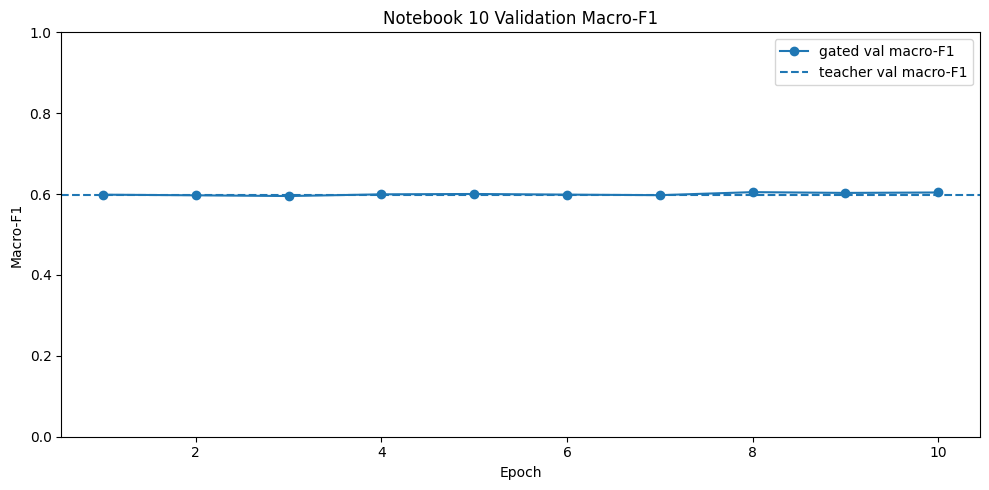

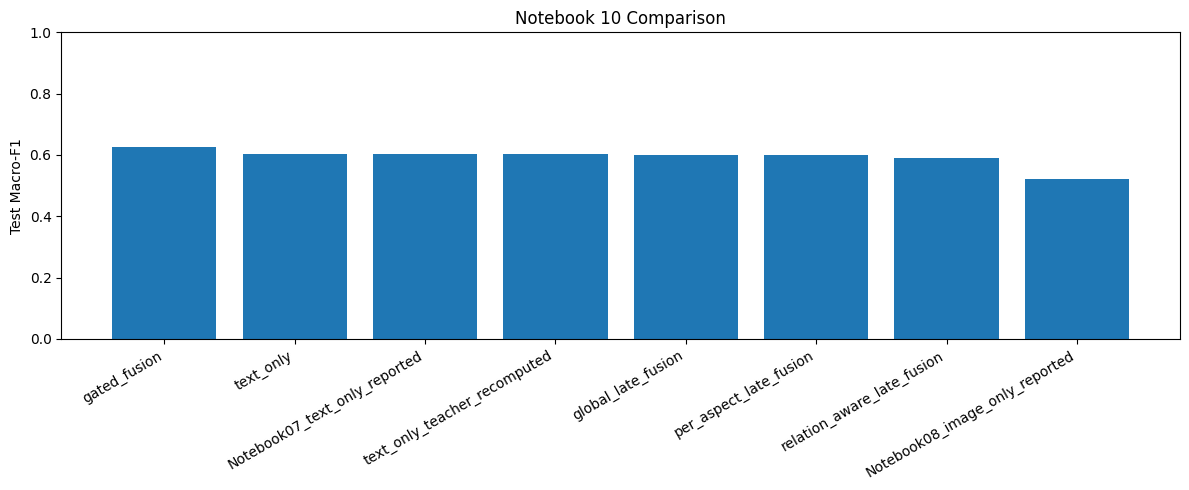

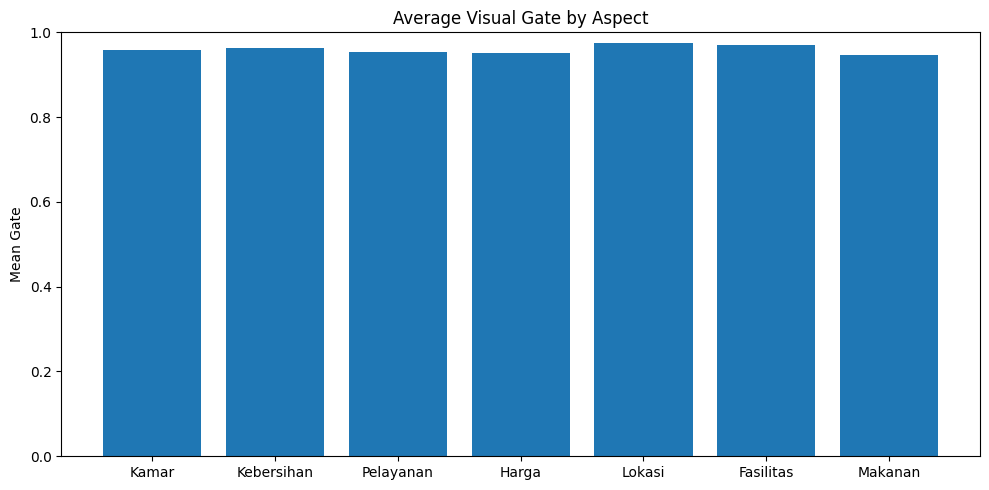

In [28]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    if len(history_df):
        plt.plot(history_df["global_epoch"], history_df["val_macro_f1"], marker="o", label="gated val macro-F1")
        plt.axhline(teacher_val_overall["macro_f1"], linestyle="--", label="teacher val macro-F1")
        plt.xlabel("Epoch")
        plt.ylabel("Macro-F1")
        plt.title("Notebook 10 Validation Macro-F1")
        plt.ylim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()

    cmp_plot = comparison_df.dropna(subset=["test_macro_f1"]).copy()
    cmp_plot = cmp_plot.sort_values("test_macro_f1", ascending=False).head(8)
    plt.figure(figsize=(12, 5))
    plt.bar(cmp_plot["model"], cmp_plot["test_macro_f1"])
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Test Macro-F1")
    plt.title("Notebook 10 Comparison")
    plt.tight_layout()
    plt.show()

    gate_plot = gate_stats_df.loc[
        gate_stats_df["split"].eq("test") & gate_stats_df["relation_group"].eq("__all__")
    ].copy()
    plt.figure(figsize=(10, 5))
    plt.bar(gate_plot["aspect"], gate_plot["gate_mean"])
    plt.ylim(0, 1)
    plt.ylabel("Mean Gate")
    plt.title("Average Visual Gate by Aspect")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Visualization skipped:", exc)

### 29. Pengarsipan dan Kompresi ZIP Seluruh Output Eksperimen Gated Fusion


In [29]:
zip_base = OUTPUT_DIR.parent / "mabsa_gated_fusion_model_outputs"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR)
print("ZIP output:", zip_path)
print("\nFiles in output directory:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

ZIP output: /kaggle/working/mabsa_gated_fusion_model_outputs.zip

Files in output directory:
- best_gated_fusion_model.pt
- class_weights_used_gated_fusion.csv
- classification_report_selected_gated_fusion.csv
- confusion_matrix_selected_gated_fusion_long.csv
- final_gated_fusion_metrics.csv
- gate_statistics_by_aspect_relation.csv
- gated_fusion_probability_cache_review_level.npz
- gated_fusion_training_config.json
- methodology_notes_notebook_10.md
- notebook07_08_09_10_comparison.csv
- notebook_10_checks.csv
- review_level_visual_features_for_gated_fusion.npz
- teacher_text_probs_from_notebook07_checkpoint.npz
- test_predictions_selected_gated_fusion.csv
- text_only_teacher_metrics_recomputed.csv
- training_history_gated_fusion.csv
- val_metrics_gated_fusion_epoch_1.csv
- val_metrics_gated_fusion_epoch_10.csv
- val_metrics_gated_fusion_epoch_2.csv
- val_metrics_gated_fusion_epoch_3.csv
- val_metrics_gated_fusion_epoch_4.csv
- val_metrics_gated_fusion_epoch_5.csv
- val_metrics_gated_